In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

In [2]:
# Read the data
data = pd.read_csv('cleaned_data.csv')

data

,time,latitude,longitude,thetao,so,uo,vo,wo,kd,ph,spco2,o2,no3,po4,si,fe,chl
0,2023-12-01,20.00,89.75,27.322805,32.201420,0.049275,0.005945,-2.852281e-06,0.056219,8.079213,34.096367,210.70331,0.489192,0.022368,2.062620,0.000735,0.317517
1,2023-12-01,20.00,90.00,27.036701,31.050486,-0.196343,-0.141262,-2.424902e-07,0.055182,8.087698,33.217445,213.05751,1.284574,0.012939,2.285833,0.000848,0.283778
2,2023-12-01,20.00,90.25,27.147812,31.393084,-0.147272,-0.081226,-4.291245e-07,0.052162,8.084445,33.597878,212.06847,1.541355,0.007112,2.627164,0.000823,0.211030
3,2023-12-01,20.00,90.50,26.790709,27.032257,-0.366206,-0.024395,3.377581e-06,0.048450,8.102618,32.234962,214.02621,3.863624,0.001202,3.391350,0.001091,0.198395
4,2023-12-01,20.00,90.75,26.970106,26.796848,-0.297612,-0.190504,2.464392e-06,0.043023,8.105902,31.920260,215.08120,4.967880,0.000403,3.820824,0.001230,0.201169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,2024-11-01,21.25,87.25,29.053162,15.295896,0.283282,-0.031796,1.820575e-06,0.047505,8.178094,19.154804,222.37024,5.992222,0.000404,1.838310,0.004654,0.202605
833,2024-11-01,21.25,88.50,29.194250,19.064146,0.066354,-0.137104,-8.132460e-07,0.090560,8.141164,23.431673,218.99768,4.637534,0.002718,2.381763,0.003174,0.486145
834,2024-11-01,21.25,88.75,29.763885,21.062641,0.017497,-0.016994,7.822443e-07,0.076014,8.133849,26.110245,216.79277,7.908310,0.003219,2.846911,0.003497,0.391611
835,2024-11-01,21.50,88.75,29.291569,22.154676,0.206255,-0.046011,-1.070541e-06,0.069274,8.115875,24.308140,213.93890,3.268801,0.003170,2.616735,0.004132,0.326283


In [3]:
# Define features and target
features = ['thetao', 'so', 'uo', 'vo', 'wo', 'kd', 'ph', 'spco2', 'o2', 'no3', 'po4', 'si', 'fe']
target = 'chl'

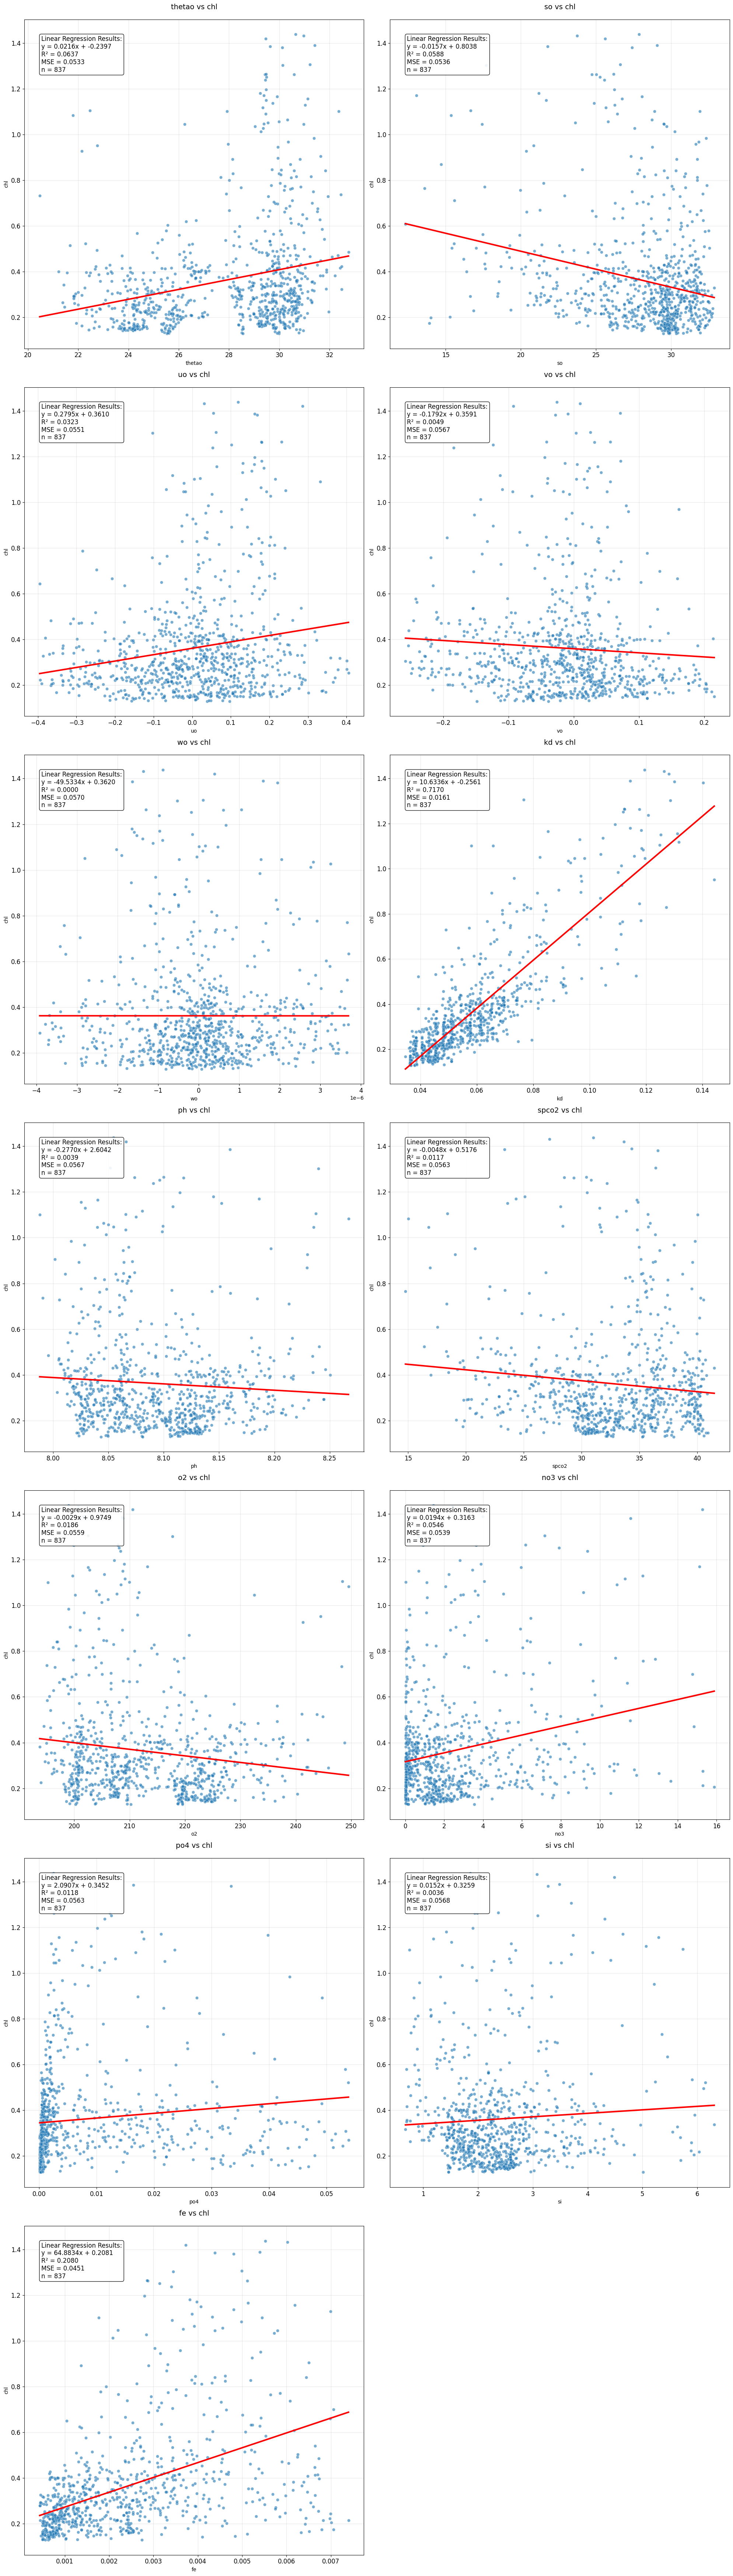

,Feature,Coefficient,Intercept,R²,MSE,Sample Size
0,thetao,0.0216,-0.2397,0.0637,0.0533,837
1,so,-0.0157,0.8038,0.0588,0.0536,837
2,uo,0.2795,0.3610,0.0323,0.0551,837
3,vo,-0.1792,0.3591,0.0049,0.0567,837
4,wo,-49.5334,0.3620,0.0000,0.0570,837
5,kd,10.6336,-0.2561,0.7170,0.0161,837
6,ph,-0.2770,2.6042,0.0039,0.0567,837
7,spco2,-0.0048,0.5176,0.0117,0.0563,837
8,o2,-0.0029,0.9749,0.0186,0.0559,837
9,no3,0.0194,0.3163,0.0546,0.0539,837


In [4]:
def plot_single_relationships(data, target, features, n_cols=2):
    """Plot scatter plots of target vs each feature with univariate best fit line and return regression details"""
    n_features = len(features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10*n_rows))
    axes = axes.ravel()
    
    # Create a list to store regression details
    regression_details = []
    
    for idx, feature in enumerate(features):
        # ... existing scatter plot code ...
        clean_data = data.dropna(subset=[feature, target])
        sns.scatterplot(data=clean_data, x=feature, y=target, ax=axes[idx], alpha=0.6)
        
        # ... existing regression code ...
        X = clean_data[feature].values.reshape(-1, 1)
        y = clean_data[target].values
        reg = LinearRegression().fit(X, y)
        y_pred = reg.predict(X)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        
        # Store regression details
        regression_details.append({
            'Feature': feature,
            'Coefficient': reg.coef_[0],
            'Intercept': reg.intercept_,
            'R²': r2,
            'MSE': mse,
            'Sample Size': len(clean_data)
        })
        
        # ... rest of the plotting code remains the same ...
        x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_pred_line = reg.predict(x_range)
        axes[idx].plot(x_range, y_pred_line, color='red', linewidth=3, label='Best fit line')
        
        text = f'Linear Regression Results:\n'
        text += f'y = {reg.coef_[0]:.4f}x + {reg.intercept_:.4f}\n'
        text += f'R² = {r2:.4f}\n'
        text += f'MSE = {mse:.4f}\n'
        text += f'n = {len(clean_data)}'
        axes[idx].text(0.05, 0.95, text, transform=axes[idx].transAxes,
                      verticalalignment='top', fontsize=12,
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        axes[idx].set_title(f'{feature} vs {target}', fontsize=14, pad=20)
        axes[idx].tick_params(labelsize=12)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots if any
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # Create and return DataFrame with regression details
    regression_df = pd.DataFrame(regression_details)
    # Round numeric columns
    numeric_columns = ['Coefficient', 'Intercept', 'R²', 'MSE']
    regression_df[numeric_columns] = regression_df[numeric_columns].round(4)
    
    # Display the table
    display(regression_df)
    
    return regression_df

# Plot relationships and get regression details
regression_results = plot_single_relationships(data, target, features)

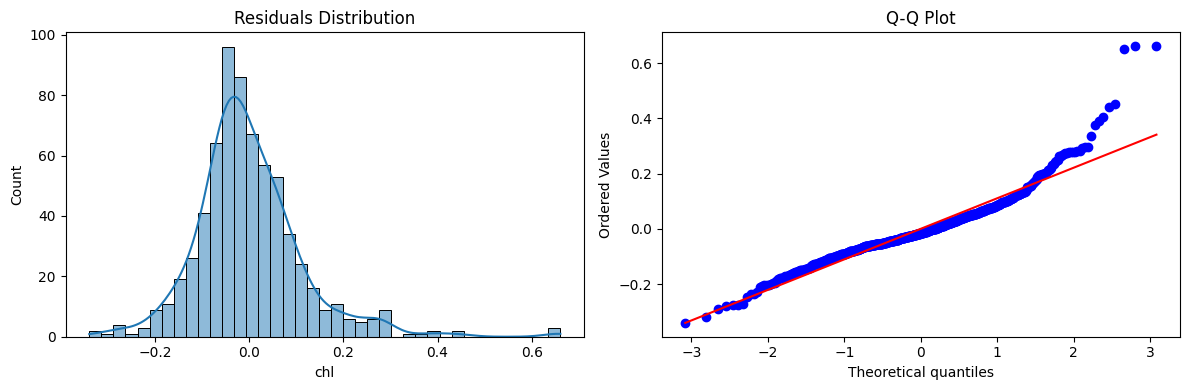

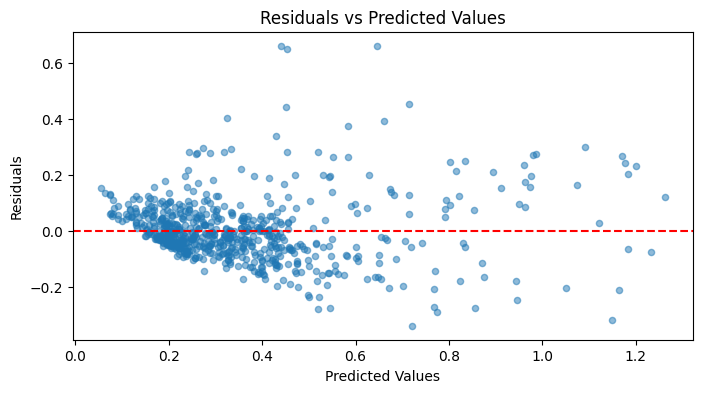


Variance Inflation Factors:
   Variable           VIF
6        ph  18637.945260
8        o2   7592.157342
0    thetao   2406.430547
1        so   1086.004117
7     spco2    891.899284
5        kd     18.775604
11       si     16.852081
12       fe      5.807439
9       no3      4.731273
10      po4      1.935344
2        uo      1.205261
3        vo      1.129519
4        wo      1.051415


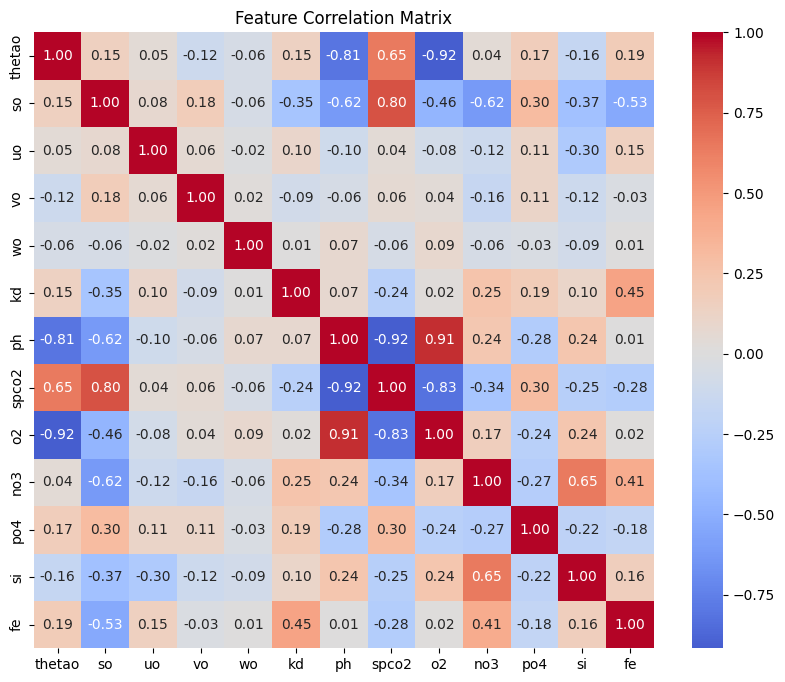

In [5]:
# Check Linear Regression Assumptions (excluding linearity)
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare data for multivariate analysis
X = data[features].dropna()
y = data[target][X.index]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit initial model for residual analysis
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
residuals = y_train - y_pred

# 2. Normality of Residuals
plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.subplot(122)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

# 3. Homoscedasticity (with smaller plot)
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

# 4. Multicollinearity Check
# Calculate and print VIF values first
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors:")
print(vif_data.sort_values('VIF', ascending=False))

# Then show correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [6]:
import statsmodels.api as sm
from sklearn.metrics import r2_score

# Adding a constant to the data for the intercept term
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fitting a linear regression model
model = sm.OLS(y_train, X_train_sm)
results = model.fit()

# Printing the summary of the linear regression model
print(results.summary())

# Making predictions with the linear regression model
predictions = results.predict(X_test_sm)

# Calculating R^2 for Linear Regression
r2 = r2_score(y_test, predictions)
print(f"\nR^2 Score for Linear Regression: {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    chl   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     168.7
Date:                Sun, 29 Dec 2024   Prob (F-statistic):          5.13e-199
Time:                        19:36:40   Log-Likelihood:                 496.52
No. Observations:                 669   AIC:                            -965.0
Df Residuals:                     655   BIC:                            -902.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7562      3.418     -0.806      0.4

In [7]:
# Robust Regression (Huber)
# Adding a constant to the data for the intercept term
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fitting a robust linear regression model using Huber's T norm
robust_model = sm.RLM(y_train, X_train_sm, M=sm.robust.norms.HuberT())
robust_results = robust_model.fit()

# Print model summary
print("\nRobust Regression (Huber) Results:")
print(robust_results.summary())

# Make predictions
robust_predictions = robust_results.predict(X_test_sm)

# Calculate and print R^2 score
robust_r2 = r2_score(y_test, robust_predictions)
print(f"\nR^2 Score for Robust Linear Regression: {robust_r2:.4f}")


Robust Regression (Huber) Results:
                    Robust linear Model Regression Results                    
Dep. Variable:                    chl   No. Observations:                  669
Model:                            RLM   Df Residuals:                      655
Method:                          IRLS   Df Model:                           13
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 29 Dec 2024                                         
Time:                        19:36:41                                         
No. Iterations:                    41                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3

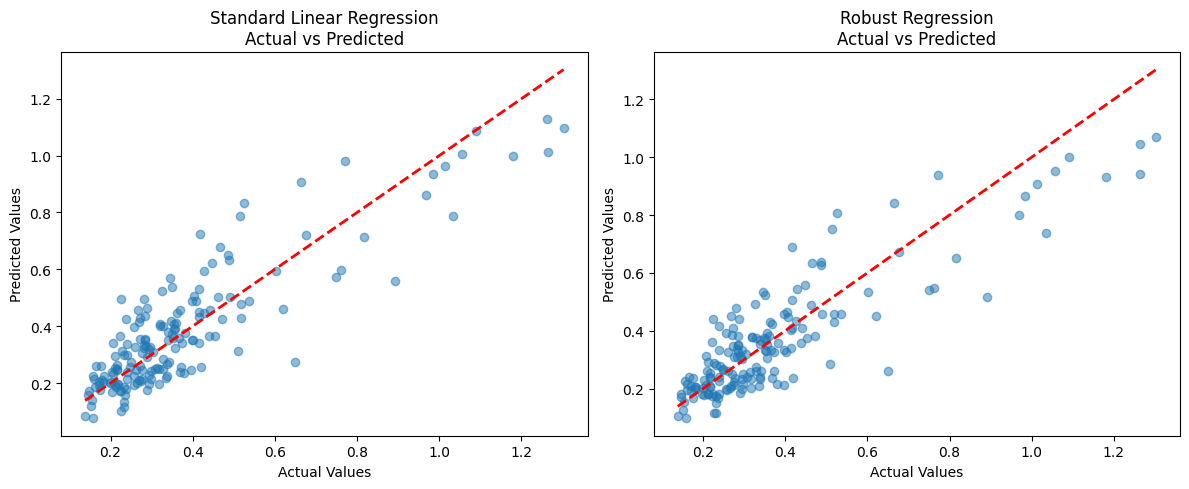

In [8]:
# Visualize actual vs predicted values
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Standard Linear Regression\nActual vs Predicted')

plt.subplot(122)
plt.scatter(y_test, robust_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Robust Regression\nActual vs Predicted')

plt.tight_layout()
plt.show()